In [ ]:
import pandas as pd
import numpy as np
import shap
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.features import build_features, FEATURE_COLS

app = pd.read_csv('../data/raw/application_train.csv')
bureau = pd.read_csv('../data/raw/bureau.csv')
df = build_features(app, bureau)

X = df[FEATURE_COLS]
y = df['TARGET']

model = joblib.load('../data/processed/lgb_model.pkl')

c:\Users\Paul\credit-scoring\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Данные загружены: (307511, 29)
Модель загружена: <class 'lightgbm.sklearn.LGBMClassifier'>


In [ ]:
X_sample = X.sample(5000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

Тип shap_values: <class 'numpy.ndarray'>
Длина: 5000
Форма первого элемента: (29,)


c:\Users\Paul\credit-scoring\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


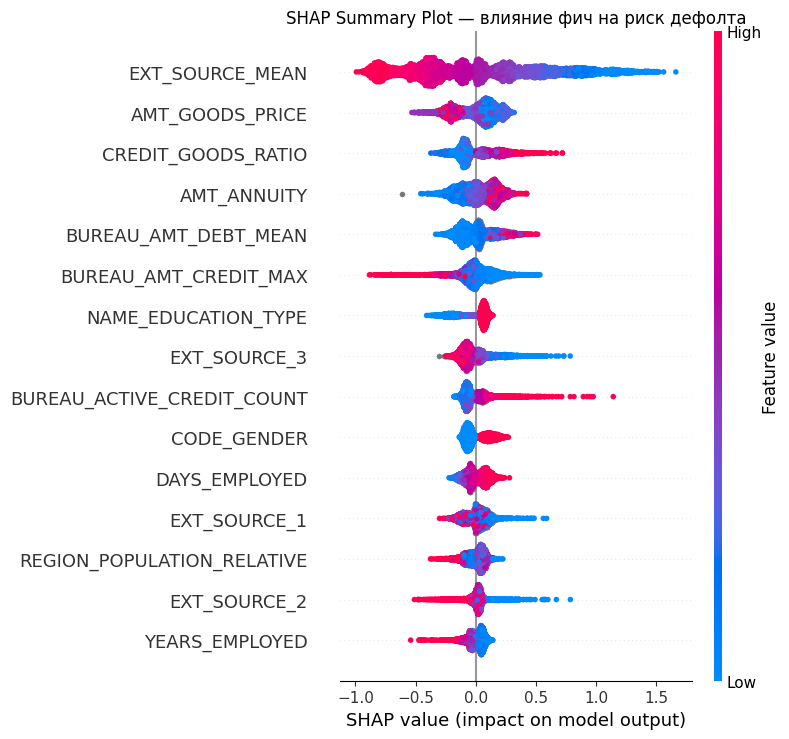

График сохранён


In [ ]:
# Summary plot
plt.figure(figsize=(10, 8))
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(
    sv,
    X_sample,
    plot_type='dot',
    max_display=15,
    show=False
)

plt.title('SHAP Summary Plot — влияние фич на риск дефолта')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Высокий риск: 0.694
Низкий риск:  0.002


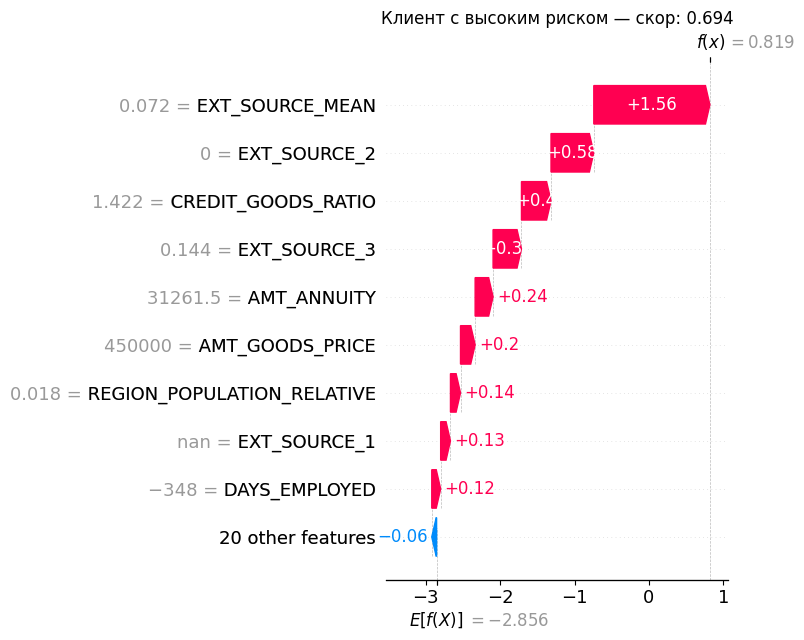

In [ ]:
predictions = model.predict_proba(X_sample)[:, 1]

high_risk_idx = predictions.argmax()   # самый рискованный
low_risk_idx = predictions.argmin()    # самый надёжный

print(f"Высокий риск: {predictions[high_risk_idx]:.3f}")
print(f"Низкий риск:  {predictions[low_risk_idx]:.3f}")

# Waterfall для высокорискованного клиента
shap_explanation = shap.Explanation(
    values=sv[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[high_risk_idx],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'Клиент с высоким риском — скор: {predictions[high_risk_idx]:.3f}')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_high.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

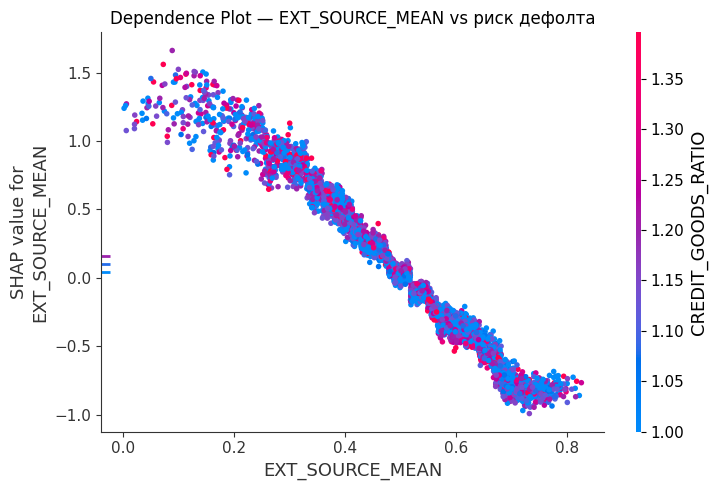

In [5]:
# Dependence plot — как EXT_SOURCE_MEAN влияет на риск
plt.figure(figsize=(10, 6))

shap.dependence_plot(
    'EXT_SOURCE_MEAN',
    sv,
    X_sample,
    interaction_index='CREDIT_GOODS_RATIO',
    show=False
)

plt.title('Dependence Plot — EXT_SOURCE_MEAN vs риск дефолта')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()